<a href="https://colab.research.google.com/github/Ansh8765/Nuclear-PINN-r-Process/blob/main/AME2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning
We need to import AME2020 first of all and define our test and train regions


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/ame2020 (1).csv') #source :  NuCLR AME2020 Dataset on Zenodo

In [ ]:
df.head(10)

,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qna_num,qna_unc,qna_round,qna_round_unc,qna_sys,qec_num,qec_unc,qec_round,qec_round_unc,qec
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,0,1,7288.971064,7288.971064,0.000013,N,7288.97106,0.00001,0.00000,...,NaN,NaN,NaN,NaN,NaN,-782.347,0.000,-782.347,0.0,-782.347
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.28310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.26540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3HE,1,2,14931.218880,14931.218880,0.000060,N,14931.21888,0.00006,2572.68044,...,NaN,NaN,20577.6189,0.0005,NaN,-18.592,0.000,-18.592,0.0,-18.592
5,3LI,0,3,28667.000000,28667.000000,2000.000000,Y,28670.00000,2000.00000,-2267.00000,...,NaN,NaN,NaN,NaN,NaN,13735.781,2000.000,13736.000,2000.0,13735.781
6,4H,3,1,24621.129000,24621.129000,100.000000,N,24620.00000,100.00000,1720.44910,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4HE,2,2,2424.915870,2424.915870,0.000150,N,2424.91587,0.00015,7073.91560,...,NaN,NaN,NaN,NaN,NaN,-22196.213,100.000,-22196.000,100.0,-22196.213
8,4LI,1,3,25323.190000,25323.190000,212.132000,N,25320.00000,210.00000,1153.76030,...,NaN,NaN,NaN,NaN,NaN,22898.274,212.132,22898.000,212.0,22898.274
9,5H,4,1,32892.447000,32892.447000,89.443000,N,32890.00000,90.00000,1336.35920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ame_filtered = df[['n','z','binding']].copy()
ame_filtered = ame_filtered.rename(columns={'n': 'N', 'z': 'Z'})
ame_filtered['A'] = ame_filtered['N'] + ame_filtered['Z']
ame_filtered['binding_MeV'] = (ame_filtered['binding'] / 1000)* ame_filtered['A'] # Convert binding energy from keV to MeV
display(ame_filtered.head(10))

,N,Z,binding,A,binding_MeV
0,1,0,0.00000,1,0.000000
1,0,1,0.00000,1,0.000000
2,1,1,1112.28310,2,2.224566
3,2,1,2827.26540,3,8.481796
4,1,2,2572.68044,3,7.718041
5,0,3,-2267.00000,3,-6.801000
6,3,1,1720.44910,4,6.881796
7,2,2,7073.91560,4,28.295662
8,1,3,1153.76030,4,4.615041
9,4,1,1336.35920,5,6.681796


In [ ]:
ame_filtered.isna().sum()

,0
N,0
Z,0
binding,0
A,0
binding_MeV,0


In [ ]:
ame_filtered.dtypes

,0
N,int64
Z,int64
binding,float64
A,int64
binding_MeV,float64


In [ ]:
#Now checking if the dataset contains physically unrealistic numbers.if yes , then i'll fix them.
print(f"Neutron (N): Min={ame_filtered['N'].min()}, Max={ame_filtered['N'].max()}")
print(f"Proton (Z): Min={ame_filtered['Z'].min()}, Max={ame_filtered['Z'].max()}")
print(f"Binding (MeV): Min={ame_filtered['binding_MeV'].min()}, Max={ame_filtered['binding_MeV'].max()}")

Neutron (N): Min=0, Max=177
Proton (Z): Min=0, Max=118
Binding (MeV): Min=-6.801, Max=2087.42


In [ ]:
# Getting rid of negative non-experimental binding energy now
ame_filtered = ame_filtered[ame_filtered['binding_MeV']>0].copy()

In [ ]:
print(f"Binding (MeV): Min={ame_filtered['binding_MeV'].min()}, Max={ame_filtered['binding_MeV'].max()}")

Binding (MeV): Min=0.09, Max=2087.42


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

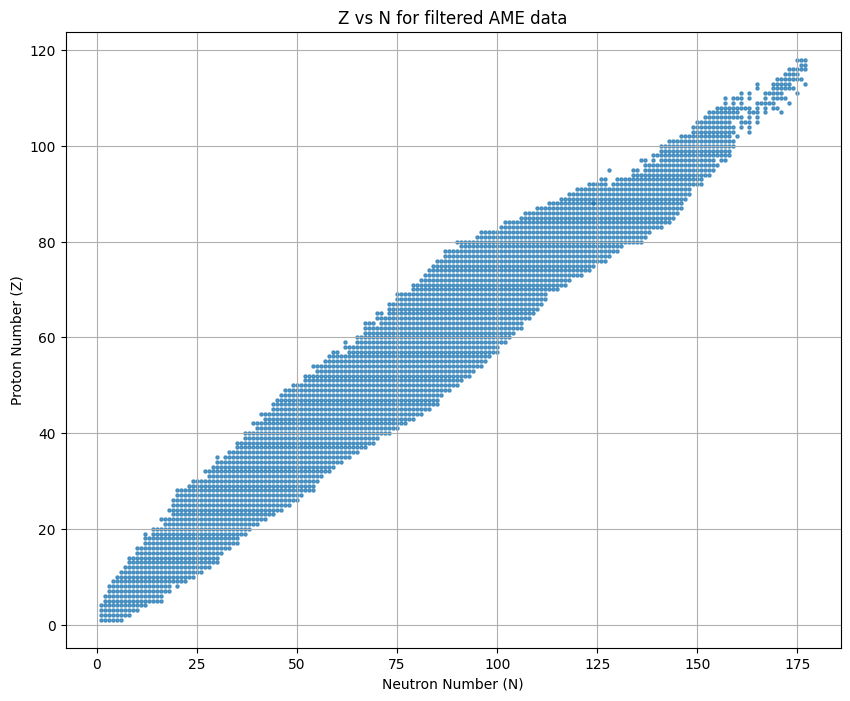

In [ ]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(ame_filtered['N'], ame_filtered['Z'], s=5, alpha=0.7)
plt.xlabel('Neutron Number (N)')
plt.ylabel('Proton Number (Z)')
plt.title('Z vs N for filtered AME data')
plt.grid(True)
plt.savefig('Z_over_N.png', dpi=300, bbox_inches='tight')
from google.colab import files
files.download('Z_over_N.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

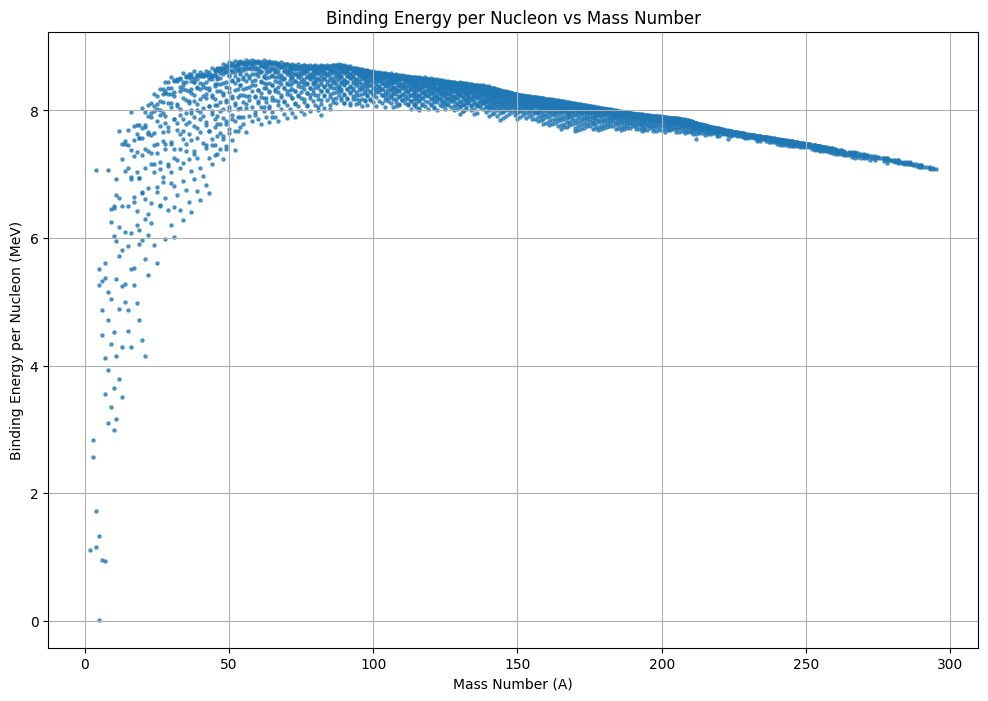

In [ ]:
ame_filtered['binding_per_nucleon_MeV'] = ame_filtered['binding_MeV'] / ame_filtered['A']
ame_filtered['N_minus_Z'] = ame_filtered['N'] - ame_filtered['Z']

#Binding Energy per Nucleon vs Mass Number (A)
fig2 = plt.figure(figsize=(12, 8))
plt.scatter(ame_filtered['A'], ame_filtered['binding_per_nucleon_MeV'], s=5, alpha=0.7)
plt.xlabel('Mass Number (A)')
plt.ylabel('Binding Energy per Nucleon (MeV)')
plt.title('Binding Energy per Nucleon vs Mass Number')
plt.grid(True)
plt.savefig('Binding_Energy_per_Nucleon_vs_A.png', dpi=300, bbox_inches='tight')
files.download('Binding_Energy_per_Nucleon_vs_A.png')
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

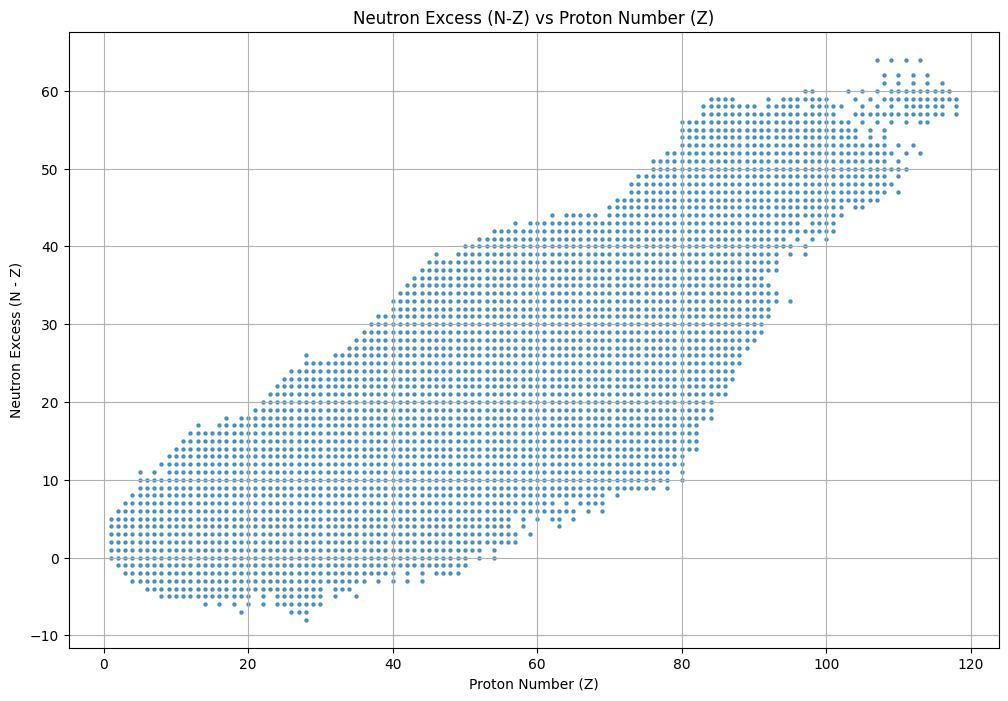

In [ ]:
#N-Z vs Z
fig3 = plt.figure(figsize=(12, 8))
plt.scatter(ame_filtered['Z'], ame_filtered['N_minus_Z'], s=5, alpha=0.7)
plt.xlabel('Proton Number (Z)')
plt.ylabel('Neutron Excess (N - Z)')
plt.title('Neutron Excess (N-Z) vs Proton Number (Z)')
plt.grid(True)
plt.savefig('Neutron_Excess_vs_Z.png', dpi=300, bbox_inches='tight')
files.download('Neutron_Excess_vs_Z.png')
plt.show()


In [ ]:
TRAIN_FRACTION = 0.70
NEAR_MAX_DISTANCE = 3
FAR_MIN_DISTANCE = 4

MIN_CHAIN_SIZE = 10
chain_size = ame_filtered.groupby("Z")["N"].transform("count")

ame_filtered = ame_filtered[chain_size >= MIN_CHAIN_SIZE].copy()


ame_filtered = ame_filtered.sort_values(["Z", "N"]).reset_index(drop=True)

frontier = (
    ame_filtered.groupby("Z")["N"]
      .quantile(TRAIN_FRACTION)
      .rename("N_frontier")
      .reset_index()
)

ame_filtered = ame_filtered.merge(frontier, on="Z", how="left")


ame_filtered["d"] = ame_filtered["N"] - ame_filtered["N_frontier"]



In [ ]:
# Training region
training = ame_filtered[ame_filtered["d"] <= 0].copy()

# Near extrapolation
near_extrapolation = ame_filtered[
    (ame_filtered["d"] >= 1) &
    (ame_filtered["d"] <= NEAR_MAX_DISTANCE)
].copy()

# Far extrapolation
far_extrapolation = ame_filtered[
    ame_filtered["d"] >= FAR_MIN_DISTANCE
].copy()

In [ ]:
# Interpolation test is a random holdout INSIDE the
# training region.

from sklearn.model_selection import train_test_split

train_set, interpolation_test = train_test_split(
    training,
    test_size=0.20,
    random_state=42
)


In [ ]:
train_set.to_csv(
    "training_set.csv",
    index=False
)

interpolation_test.to_csv(
    "interpolation_test.csv",
    index=False
)

near_extrapolation.to_csv(
    "near_extrapolation_test.csv",
    index=False
)

far_extrapolation.to_csv(
    "far_extrapolation_test.csv",
    index=False
)


In [ ]:

print("Training:", len(train_set))
print("Interpolation test:", len(interpolation_test))
print("Near extrapolation:", len(near_extrapolation))
print("Far extrapolation:", len(far_extrapolation))

Training: 1839
Interpolation test: 460
Near extrapolation: 223
Far extrapolation: 604


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

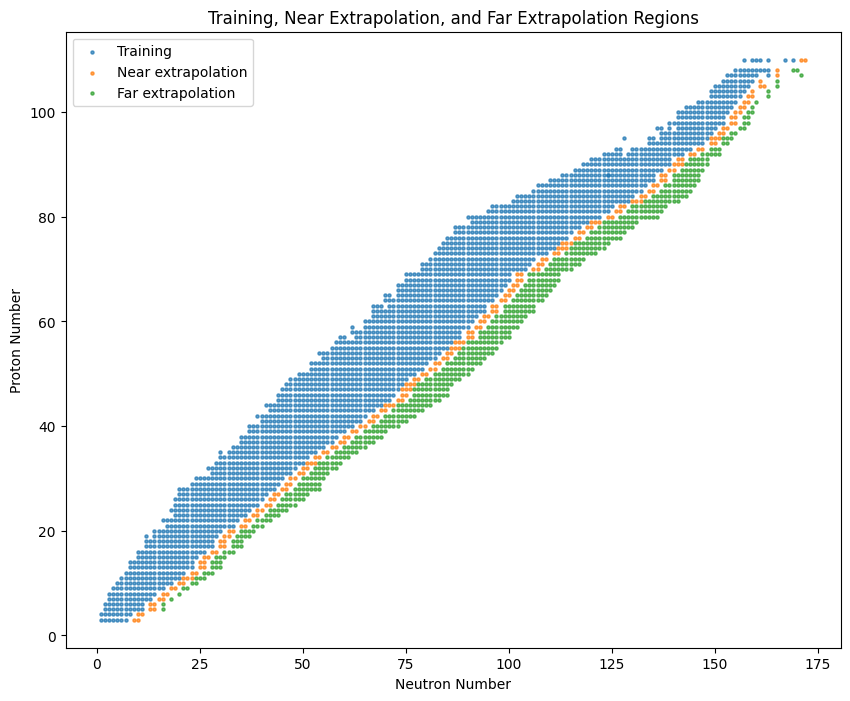

In [ ]:
plt.figure(figsize = (10,8))
plt.scatter(
    training['N'],
    training['Z'],
    label ='Training',
    s=5,
    alpha=0.7)
plt.scatter(
    near_extrapolation['N'],
    near_extrapolation['Z'],
    label ='Near extrapolation',
    s=5,
    alpha=0.7)
plt.scatter(
    far_extrapolation['N'],
    far_extrapolation['Z'],
    label ='Far extrapolation',
    s=5,
    alpha=0.7)
plt.xlabel('Neutron Number')
plt.ylabel('Proton Number')
plt.title('Training, Near Extrapolation, and Far Extrapolation Regions')
plt.legend()
plt.savefig('regions.png', dpi=300, bbox_inches='tight')
files.download('regions.png')
plt.show()
